<sub>Developed by SeongKu Kang, August 2025 — Do not distribute</sub>

# 📘 Guide

This notebook serves as a **guideline for our tasks**, with an example of **Task 1: Product Category Classification**.  
We will experiment with two approaches:

1. **TF-IDF similarity** between product text and category labels  
2. **TF-IDF vectors + a linear classifier** for supervised learning  

These two methods will help us understand both simple similarity-based classification and a more generalizable supervised model.  
It is strongly recommended that you fully understand this guideline, as it will be essential for the subsequent tasks.

⚠️ **Note**  
All the code we provide (in this notebook and future ones) is **not optimized**. It is intentionally simplified to highlight and demonstrate the **core concepts**.  
Achieving better performance in real-world applications will require further effort, optimization, and the use of more advanced techniques.

In [281]:
import json
from pathlib import Path
import torch
import copy
from torch.utils.data import Dataset, DataLoader, random_split, ConcatDataset
import sys
import os

# Add the assignment_release directory to the path
sys.path.append("../assignment_release")

from utils import * 
import torch.nn.functional as F
from tqdm import tqdm
from sklearn.metrics import accuracy_score, f1_score

device = "cuda" if torch.cuda.is_available() else "cpu"

In [282]:
# Default paths
ROOT = Path("../assignment_release/dataset") # Root dataset directory
CORPUS_PATH = ROOT / "corpus.jsonl" # Product corpus file (JSON Lines): Each line contains a product ID and its associated text description.

# Task 1: Product category classification
LABEL_MAP_PATH = ROOT / "category_classification" # Folder containing label mapping files and product-to-label mappings
LABEL2ID_PATH = LABEL_MAP_PATH / "label2labelid.json" # Mapping from category label string → numeric label ID
ID2LABEL_PATH = LABEL_MAP_PATH / "labelid2label.json" # Mapping from numeric label ID → category label string
PID2LABEL_TRAIN_PATH = LABEL_MAP_PATH / "pid2labelids_train.json" # Mapping from product ID → label ID for the training set
PID2LABEL_TEST_PATH = LABEL_MAP_PATH / "pid2labelids_test.json" # Mapping from product ID → label ID for the test set

In [283]:
pid2text = load_corpus(CORPUS_PATH) # load corpus

label2id = load_json(LABEL2ID_PATH)
id2label = load_json(ID2LABEL_PATH)
pid2label_train = load_json(PID2LABEL_TRAIN_PATH)
pid2label_test = load_json(PID2LABEL_TEST_PATH)

In [284]:
import random, numpy as np, torch

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

## [Part A] Classification attempt 1: lexical similarity with TF-IDF 

In this first attempt, we will use a **lexical similarity approach** based on TF-IDF.  
The idea is straightforward: represent both **product descriptions** and **category labels** as TF-IDF vectors, and then compute their similarity (e.g., cosine similarity).  

This method does not involve learning parameters — it simply measures surface-level word overlap.  
While limited, it provides a simple baseline to check whether lexical features alone are sufficient for product classification.

In [285]:
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np
import re

def preprocess_label_text(label_path_str):
    """
    Cleans label string by splitting on '>', '&', and other special characters,
    and returns a space-separated token string.
    """
    cleaned = re.sub(r"[>&]", " ", label_path_str)
    cleaned = re.sub(r"[^a-zA-Z0-9 ]", "", cleaned)
    cleaned = re.sub(r"\s+", " ", cleaned).strip()
    return cleaned

In [286]:
def build_tfidf_vectorizer(label_texts):
    """
    Build and fit a TF-IDF vectorizer on label texts.

    Args:
        label_texts (list of str): A list of strings, each describing a label/category.

    Returns:
        vectorizer (TfidfVectorizer): The fitted TF-IDF vectorizer.
        label_tfidf (scipy.sparse.csr_matrix): TF-IDF matrix representation of label_texts.
    """
    vectorizer = TfidfVectorizer()
    label_tfidf = vectorizer.fit_transform(label_texts)
    return vectorizer, label_tfidf


def compute_lexical_similarity(doc_text, vectorizer, label_tfidf):
    """
    Compute lexical similarity between a document and label texts using TF-IDF.

    Args:
        doc_text (str): The document (e.g., product description) as a string.
        vectorizer (TfidfVectorizer): The fitted TF-IDF vectorizer.
        label_tfidf (scipy.sparse.csr_matrix): TF-IDF matrix for label_texts.

    Returns:
        sims (numpy.ndarray): A 1D array of similarity scores for each label 
                              (e.g., cosine similarity values).
    """
    doc_vec = vectorizer.transform([doc_text])
    sims = cosine_similarity(doc_vec, label_tfidf)[0]
    return sims

In [287]:
# === Prepare label texts and build TF-IDF representations ===
label_ids = sorted(list(id2label.keys()), key=lambda x: int(x))
label_texts = [preprocess_label_text(id2label[label_id]) for label_id in label_ids]
vectorizer, label_tfidf = build_tfidf_vectorizer(label_texts)

In [288]:
# === Example: Inspect how a label text is vectorized with TF-IDF ===
sample_text = label_texts[0]                              # pick one example label text
print("Sample label text:", sample_text)

sample_vec = vectorizer.transform([sample_text])          # transform into TF-IDF vector
dense_vec = sample_vec.toarray()[0]                       # convert sparse matrix to dense array
feature_names = vectorizer.get_feature_names_out()        # get vocabulary (words)

for word, score in zip(feature_names, dense_vec):         # print nonzero entries only
    if score > 0:
        print(f"{word}: {score:.4f}")

Sample label text: Appliances Parts Accessories Dryer Parts Accessories Replacement Parts
accessories: 0.2862
appliances: 0.2898
dryer: 0.3986
parts: 0.7656
replacement: 0.2984


In [289]:
# === Evaluate TF-IDF classifier on the test set ===
y_true, y_pred = [], []

for pid, text in tqdm(pid2text.items(), desc="Evaluating TF-IDF classifier"):
    if pid not in pid2label_test:
        continue
    sims = compute_lexical_similarity(text, vectorizer, label_tfidf)
    pred_label = int(np.argmax(sims))

    y_true.append(pid2label_test[pid])
    y_pred.append(pred_label)

# Compute evaluation metrics
acc = accuracy_score(y_true, y_pred)
f1_macro = f1_score(y_true, y_pred, average="macro", zero_division=0)

# Print results
print_eval_result({"accuracy": acc, "f1_macro": f1_macro}, stage="test")

Evaluating TF-IDF classifier: 100%|██████████| 39452/39452 [00:01<00:00, 25286.75it/s]

[TEST] Acc: 0.2690 | F1-macro: 0.2487


## [Part B] Classification attempt 2: linear classifier with TF-IDF 

In this second approach, we go beyond simple lexical similarity and use a **supervised model**.  
Here, each product text is represented as a **TF-IDF vector**, which is then fed into a **linear classifier**.

The model learns to map TF-IDF features to the correct product category by training on labeled data.  
Unlike the similarity-based method, this approach can capture more complex decision boundaries, making it more flexible and potentially more accurate for classification tasks.

In [290]:
# === Prepare corpus texts and TF-IDF vectors ===

# Extract product IDs and corresponding texts
pid_list = list(pid2text.keys())
texts = [pid2text[pid] for pid in pid_list]

# Map product IDs to index positions
pid2idx = {pid: i for i, pid in enumerate(pid_list)}

# Vectorize texts with TF-IDF (limit vocabulary size to 500 features)
vectorizer = TfidfVectorizer(max_features=30000)
corpus_vectors = vectorizer.fit_transform(texts).toarray()

# Convert to PyTorch tensor for model training
corpus_vectors = torch.tensor(corpus_vectors, dtype=torch.float)

In [291]:
from sklearn.metrics import accuracy_score, f1_score

def evaluate(model, dataloader, device="cpu"):
    """
    Evaluate a classification model on a given dataset.

    Args:
        model (torch.nn.Module): The classification model to evaluate.
        dataloader (DataLoader): DataLoader providing batches of {"X": features, "y": labels}.
        device (str, optional): Device to run evaluation on ("cpu" or "cuda"). Default is "cpu".

    Returns:
        dict: A dictionary containing:
            - "accuracy": Overall accuracy of predictions.
            - "f1_macro": Macro-averaged F1 score across all classes.
    """
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for batch in dataloader:
            X = batch["X"].to(device)
            y = batch["y"].to(device)
            logits = model(X)
            preds = torch.argmax(logits, dim=1)
            all_preds.extend(preds.cpu().tolist())
            all_labels.extend(y.cpu().tolist())

    acc = accuracy_score(all_labels, all_preds)
    f1_macro = f1_score(all_labels, all_preds, average="macro", zero_division=0)

    return {"accuracy": acc, "f1_macro": f1_macro}

In [292]:
from torch.utils.data import Dataset

class ProductCategoryTfidfDataset(Dataset):
    """
    A PyTorch Dataset for product category classification using TF-IDF embeddings.

    Args:
        pid2label (dict): Mapping from product ID to its label (category index).
        pid2idx (dict): Mapping from product ID to its index in the embedding matrix.
        embeddings (torch.Tensor or np.ndarray): TF-IDF embedding matrix of products.

    Attributes:
        pids (list): List of product IDs in the dataset.
        labels (list): List of labels corresponding to each product ID.
        indices (list): List of indices mapping products to their embeddings.
        vecs (torch.Tensor): Embedding matrix used for feature lookup.
    """
    def __init__(self, pid2label, pid2idx, embeddings):
        self.pids = list(pid2label.keys())
        self.labels = [pid2label[pid] for pid in self.pids]
        self.indices = [pid2idx[pid] for pid in self.pids]
        self.vecs = embeddings 

    def __len__(self):
        """Return the number of products in the dataset."""
        return len(self.pids)

    def __getitem__(self, idx):
        """
        Retrieve one sample from the dataset.

        Args:
            idx (int): Index of the sample.

        Returns:
            dict: A dictionary with:
                - "X": TF-IDF embedding vector of the product
                - "y": Label (as a torch.LongTensor)
        """
        emb = self.vecs[self.indices[idx]]
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return {"X": emb, "y": label}

In [293]:
import torch.nn as nn

class BaseClassifier(nn.Module):
    """
    A simple baseline classifier using a single linear layer.

    Args:
        input_dim (int): Dimension of the input features (e.g., TF-IDF vector size).
        num_classes (int, optional): Number of output classes. Default is 100.

    Forward Input:
        x (torch.Tensor): Input tensor of shape (batch_size, input_dim).

    Forward Output:
        torch.Tensor: Logits of shape (batch_size, num_classes).
    """

    def __init__(self, input_dim, num_classes=100):
        super().__init__()
        self.linear = nn.Linear(input_dim, num_classes)
    
    def forward(self, x):
        return self.linear(x)

In [294]:
# === Prepare test dataset and data loader ===
test_dataset = ProductCategoryTfidfDataset(pid2label_test, pid2idx, corpus_vectors)
test_loader = DataLoader(test_dataset, batch_size=64)

# === Define model dimensions ===
input_dim = corpus_vectors.shape[1]       # size of TF-IDF vector
num_classes = len(label2id)               # number of unique category labels

In [295]:
# === Split training dataset into train/validation sets (80:20) ===
train_dataset = ProductCategoryTfidfDataset(pid2label_train, pid2idx, corpus_vectors)

val_ratio = 0.2
val_size = int(len(train_dataset) * val_ratio)
train_size = len(train_dataset) - val_size

# train_split, val_split = random_split(train_dataset, [train_size, val_size])
train_split, val_split = random_split(
    train_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(seed)
)

# === Create DataLoaders for training and validation ===
train_loader = DataLoader(train_split, batch_size=32, shuffle=True)
val_loader = DataLoader(val_split, batch_size=64)

In [296]:
import torch.nn as nn

class MLPClassifier(nn.Module):
    def __init__(self, input_dim, num_classes, hidden=512, p=0.3, act="relu", use_ln=True):
        super().__init__()
        Act = nn.ReLU if act=="relu" else nn.GELU
        layers = [nn.Linear(input_dim, hidden)]
        if use_ln:
            layers += [nn.LayerNorm(hidden)]
        layers += [Act(), nn.Dropout(p), nn.Linear(hidden, num_classes)]
        self.net = nn.Sequential(*layers)
    def forward(self, x):
        return self.net(x)

In [297]:
# === Initialize model and optimizer ===
model = MLPClassifier(input_dim, num_classes=num_classes).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)

In [298]:
# === Training loop ===
test_acc_list = []

EPOCHS = 100

for epoch in range(1, EPOCHS + 1):
    # --- Training phase ---
    model.train()
    total_loss = 0

    for batch in tqdm(train_loader, desc=f"Epoch {epoch}"):
        X = batch["X"].to(device)
        y = batch["y"].to(device)
        logits = model(X)
        loss = F.cross_entropy(logits, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    print(f"[Epoch {epoch}] Train Loss: {avg_loss:.4f}")

    # --- Test evaluation ---
    test_result = evaluate(model, test_loader, device=device)
    test_acc = test_result["accuracy"]
    test_acc_list.append(test_acc)
    print_eval_result(test_result, stage="test")

Epoch 1: 100%|██████████| 333/333 [00:11<00:00, 29.60it/s]


[Epoch 1] Train Loss: 3.2608
[TEST] Acc: 0.7364 | F1-macro: 0.6768


Epoch 2: 100%|██████████| 333/333 [00:11<00:00, 29.41it/s]


[Epoch 2] Train Loss: 0.3359
[TEST] Acc: 0.7550 | F1-macro: 0.7287


Epoch 3: 100%|██████████| 333/333 [00:11<00:00, 29.35it/s]


...

[Epoch 98] Train Loss: 0.0027
[TEST] Acc: 0.7023 | F1-macro: 0.6836


Epoch 99: 100%|██████████| 333/333 [00:12<00:00, 26.79it/s]


[Epoch 99] Train Loss: 0.0026
[TEST] Acc: 0.7030 | F1-macro: 0.6858


Epoch 100: 100%|██████████| 333/333 [00:12<00:00, 27.33it/s]


[Epoch 100] Train Loss: 0.0020
[TEST] Acc: 0.7055 | F1-macro: 0.6868


In [299]:
final_test_result = evaluate(model, test_loader, device=device)
print_eval_result(final_test_result, stage="final_test")

[FINAL_TEST] Acc: 0.7055 | F1-macro: 0.6868


### 📝 Your Task: Assignment Instructions

Now, your task is to improve the above Training loop:

1. **Implement validation logic**  
   - Evaluate the model on the validation set using `evaluate()`.  
   - Track validation accuracy across epochs.  
   - Save the best model state whenever validation accuracy improves.  
   - Implement early stopping with a patience counter.  

2. **Ensure that your training loop**  
   - Keeps track of both validation and test accuracy.  
   - Prints validation results similar to test results.
     
3. **Adjust other hyperparameters to achieve higher performance**
   - Try tuning learning rate, batch size, optimizer, etc. 

4. **Submit your solution**  
   - After completing the validation part with early stopping and best model checkpointing.  

In [300]:
# === Initialize model and optimizer ===
model = MLPClassifier(input_dim, num_classes=num_classes).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)

In [301]:
# Write your code here
# === Training loop with validation, test evaluation, and early stopping ===
import math
import torch.nn as nn
from torch.optim.lr_scheduler import ReduceLROnPlateau, CosineAnnealingLR

# === Enhanced hyperparameters ===
EPOCHS = 200
patience = 10          # Increased patience for better convergence
min_delta = 1e-5       # '개선'으로 인정할 최소 변화량
learning_rate = 2e-3   # Slightly higher learning rate
weight_decay = 1e-4    # L2 regularization

# === Reinitialize model and optimizer with better settings ===
model = MLPClassifier(input_dim, num_classes=num_classes).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5)

# === Add label smoothing for better generalization ===
label_smoothing = 0.15

history = {
    "train_loss": [],
    "val_acc": [],
    "val_f1": [],
    "test_acc": [],
    "test_f1": [],
    "learning_rate": []
}

best_val = -math.inf   # 모니터링 지표: validation accuracy
best_epoch = 0
wait = 0
best_model_state = None

print(f"Starting training with enhanced settings:")
print(f"- Learning rate: {learning_rate}")
print(f"- Weight decay: {weight_decay}")
print(f"- Label smoothing: {label_smoothing}")
print(f"- Patience: {patience}")
print(f"- Epochs: {EPOCHS}")

for epoch in range(1, EPOCHS + 1):
    # --- Training ---
    model.train()
    total_loss = 0.0
    num_batches = 0
    
    for batch in tqdm(train_loader, desc=f"Epoch {epoch}"):
        X = batch["X"].to(device)
        y = batch["y"].to(device)
        
        # Forward pass
        logits = model(X)
        
        # Use label smoothing for better generalization
        loss = F.cross_entropy(logits, y, label_smoothing=label_smoothing)
        
        # Backward pass with gradient clipping
        optimizer.zero_grad()
        loss.backward()
        
        # Gradient clipping to prevent exploding gradients
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        total_loss += loss.item()
        num_batches += 1

    avg_loss = total_loss / max(1, num_batches)
    history["train_loss"].append(avg_loss)
    history["learning_rate"].append(optimizer.param_groups[0]['lr'])

    # --- Validation & Test ---
    val_result = evaluate(model, val_loader, device=device)
    test_result = evaluate(model, test_loader, device=device)

    history["val_acc"].append(val_result["accuracy"])
    history["val_f1"].append(val_result["f1_macro"])
    history["test_acc"].append(test_result["accuracy"])
    history["test_f1"].append(test_result["f1_macro"])

    print(f"[Epoch {epoch}] TrainLoss={avg_loss:.4f} | "
          f"Val acc={val_result['accuracy']:.4f}, f1={val_result['f1_macro']:.4f} | "
          f"Test acc={test_result['accuracy']:.4f}, f1={test_result['f1_macro']:.4f} | "
          f"LR={optimizer.param_groups[0]['lr']:.6f}")

    # --- Learning rate scheduling ---
    scheduler.step(val_result["accuracy"])

    # --- Best model tracking ---
    if val_result["accuracy"] > best_val + min_delta:
        best_val = val_result["accuracy"]
        best_epoch = epoch
        wait = 0
        best_model_state = copy.deepcopy(model.state_dict())
        print(f"  → New best validation accuracy: {best_val:.4f}")
    else:
        wait += 1

    # --- Early stopping ---
    if wait > patience:
        print(f"Early stopping at epoch {epoch}. Best epoch={best_epoch}, "
              f"val_acc={best_val:.4f}")
        break

if best_model_state is None:
    best_model_state = copy.deepcopy(model.state_dict())

print(f"\nTraining completed!")
print(f"Best validation accuracy: {best_val:.4f} at epoch {best_epoch}")

Starting training with enhanced settings:
- Learning rate: 0.002
- Weight decay: 0.0001
- Label smoothing: 0.15
- Patience: 10
- Epochs: 200


Epoch 1: 100%|██████████| 333/333 [00:13<00:00, 24.56it/s]


[Epoch 1] TrainLoss=4.2121 | Val acc=0.7068, f1=0.6115 | Test acc=0.7139, f1=0.6542 | LR=0.002000
  → New best validation accuracy: 0.7068


Epoch 2: 100%|██████████| 333/333 [00:13<00:00, 24.57it/s]


[Epoch 2] TrainLoss=2.2020 | Val acc=0.7486, f1=0.6632 | Test acc=0.7367, f1=0.6987 | LR=0.002000
  → New best validation accuracy: 0.7486


...

[Epoch 41] TrainLoss=1.5051 | Val acc=0.7960, f1=0.7232 | Test acc=0.7791, f1=0.7378 | LR=0.000500


Epoch 42: 100%|██████████| 333/333 [00:13<00:00, 24.12it/s]


[Epoch 42] TrainLoss=1.5035 | Val acc=0.7956, f1=0.7200 | Test acc=0.7823, f1=0.7411 | LR=0.000500


Epoch 43: 100%|██████████| 333/333 [00:13<00:00, 24.05it/s]


[Epoch 43] TrainLoss=1.5041 | Val acc=0.7922, f1=0.7156 | Test acc=0.7821, f1=0.7409 | LR=0.000500
Early stopping at epoch 43. Best epoch=32, val_acc=0.7960

Training completed!
Best validation accuracy: 0.7960 at epoch 32


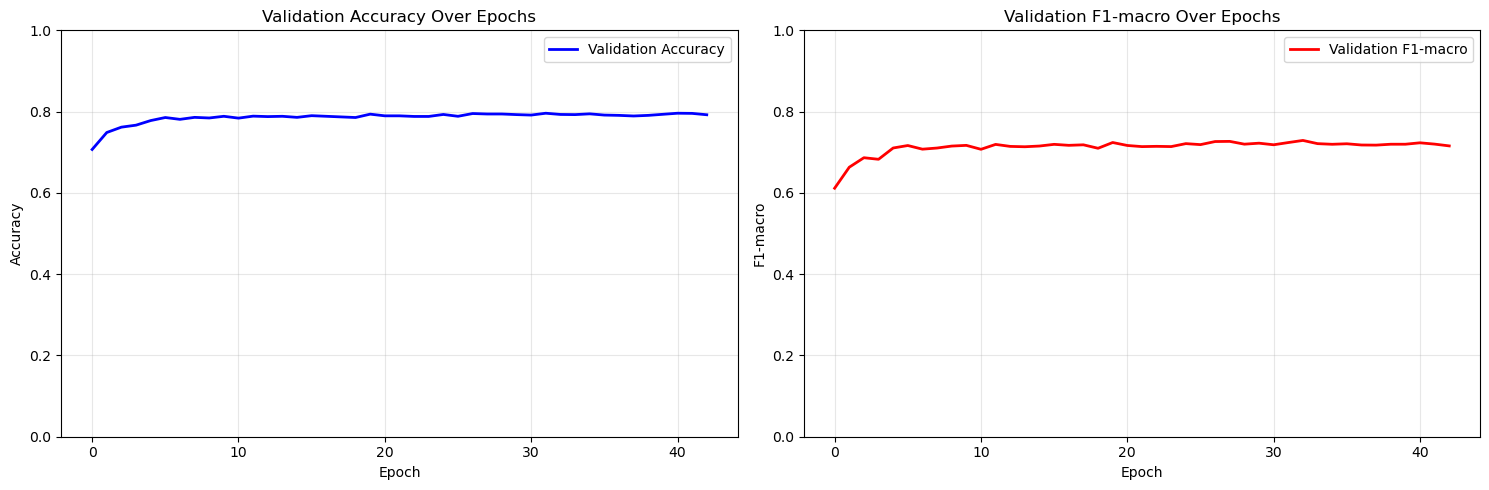


=== Training Statistics ===
Best validation accuracy: 0.7960 at epoch 32
Best validation F1-macro: 0.7291 at epoch 33
Final validation accuracy: 0.7922
Final validation F1-macro: 0.7156


In [302]:
# === Plot validation accuracy and F1-macro over epochs ===
import matplotlib.pyplot as plt

# Create figure with subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot validation accuracy
ax1.plot(history["val_acc"], 'b-', linewidth=2, label='Validation Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.set_title('Validation Accuracy Over Epochs')
ax1.grid(True, alpha=0.3)
ax1.legend()
ax1.set_ylim(0, 1)

# Plot validation F1-macro
ax2.plot(history["val_f1"], 'r-', linewidth=2, label='Validation F1-macro')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('F1-macro')
ax2.set_title('Validation F1-macro Over Epochs')
ax2.grid(True, alpha=0.3)
ax2.legend()
ax2.set_ylim(0, 1)

plt.tight_layout()
plt.show()

# Print final statistics
print(f"\n=== Training Statistics ===")
print(f"Best validation accuracy: {max(history['val_acc']):.4f} at epoch {history['val_acc'].index(max(history['val_acc'])) + 1}")
print(f"Best validation F1-macro: {max(history['val_f1']):.4f} at epoch {history['val_f1'].index(max(history['val_f1'])) + 1}")
print(f"Final validation accuracy: {history['val_acc'][-1]:.4f}")
print(f"Final validation F1-macro: {history['val_f1'][-1]:.4f}")


In [303]:
# === Load the best model and evaluate on the test set ===
model.load_state_dict(best_model_state)

final_test_result = evaluate(model, test_loader, device=device)
print_eval_result(final_test_result, stage="final_test")

[FINAL_TEST] Acc: 0.7791 | F1-macro: 0.7405


## Prepare kaggle submission

In [304]:
import torch
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from pathlib import Path

# === 1. Load test IDs ===
ROOT = Path("../assignment_release/dataset") # Root dataset directory
LABEL_MAP_PATH = ROOT / "category_classification"
TEST_IDS_PATH = LABEL_MAP_PATH / "task1_test_ids.csv"

test_ids_df = pd.read_csv(TEST_IDS_PATH)  # has column "id"
test_ids = test_ids_df["id"].tolist()

# === 2. Custom Dataset (no labels) ===
class ProductCategoryTestDataset(Dataset):
    def __init__(self, pids, pid2idx, embeddings):
        self.pids = pids
        self.indices = [pid2idx[pid] for pid in self.pids]
        self.vecs = embeddings 
        
    def __len__(self):
        return len(self.pids)

    def __getitem__(self, idx):
        pid = self.pids[idx]
        emb = self.vecs[self.indices[idx]]
        return {"X": torch.tensor(emb, dtype=torch.float)}

# === 3. Build dataset and loader ===
test_dataset_kaggle = ProductCategoryTestDataset(test_ids, pid2idx, corpus_vectors)
test_loader_kaggle = DataLoader(test_dataset_kaggle, batch_size=64)

# === 4. Run predictions ===
model.eval()
all_preds = []

with torch.no_grad():
    for batch in test_loader_kaggle:
        X = batch["X"].to(device)   # or "cuda" if using GPU
        logits = model(X)
        preds = torch.argmax(logits, dim=1)
        all_preds.extend(preds.cpu().tolist())

# === 5. Build submission file ===
submission = pd.DataFrame({
    "id": test_ids,
    "label": all_preds
})

SUBMISSION_PATH = ROOT / "submission/P1_submission_25.csv"
submission.to_csv(SUBMISSION_PATH, index=False)

print(f"Submission file saved to {SUBMISSION_PATH}")
print(submission.head())

Submission file saved to ../assignment_release/dataset/submission/P1_submission_25.csv
           id  label
0  B07X74M6PT    377
1  B07FDRHFWM    770
2  B07MQNYJKB    519
3  B07GDQNZSV    529
4  B08X43BL62    548
